In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import sklearn
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split

In [2]:
df = pd.read_excel("premiums_young.xlsx")
df.head(3)

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857


In [3]:
df.shape

(20096, 13)

In [4]:
df.columns = df.columns.str.replace(" ", "_").str.lower()

In [5]:
df.head(2)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050


<h2 align="center" style="color:blue">Exploratory Data Analysis & Data Cleaning</h2>

#### Handling null and duplicated values

In [6]:
df.isnull().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           2
employment_status        1
income_level             4
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
dtype: int64

In [7]:
df["smoking_status"].unique()

array(['Regular', 'No Smoking', 'Occasional', 'Smoking=0',
       'Does Not Smoke', 'Not Smoking', nan], dtype=object)

In [8]:
df["income_level"].dtype

dtype('O')

In [9]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(missing_values = np.nan, strategy="most_frequent")
df[["smoking_status"]] = imputer.fit_transform(df[["smoking_status"]])

In [10]:
df["smoking_status"].unique()

array(['Regular', 'No Smoking', 'Occasional', 'Smoking=0',
       'Does Not Smoke', 'Not Smoking'], dtype=object)

In [11]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(missing_values = np.nan, strategy="most_frequent")
df[["income_level"]] = imputer.fit_transform(df[["income_level"]])

In [12]:
df["income_level"].unique()

array(['> 40L', '<10L', '10L - 25L', '25L - 40L'], dtype=object)

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,20096.000000,20096.000000,20096.000000,20096.000000
mean,21.494029,0.718004,22.506519,8141.941033
std,2.294050,0.940767,23.418644,2749.609551
min,18.000000,-3.000000,1.000000,3501.000000
25%,19.000000,0.000000,6.000000,6022.000000
50%,21.500000,0.000000,16.000000,7939.000000
75%,23.000000,1.000000,31.000000,9561.000000
max,25.000000,3.000000,790.000000,18186.000000


In [15]:
df[df['number_of_dependants']<0]['number_of_dependants'].unique()

array([-3, -1])

In [16]:
df["number_of_dependants"] = abs(df["number_of_dependants"])

In [17]:
df["number_of_dependants"].describe()

count    20096.000000
mean         0.722582
std          0.937255
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          3.000000
Name: number_of_dependants, dtype: float64

#### Handling outliers

#### 1. Numerical columns

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20096 entries, 0 to 20095
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   age                    20096 non-null  int64 
 1   gender                 20096 non-null  object
 2   region                 20096 non-null  object
 3   marital_status         20096 non-null  object
 4   number_of_dependants   20096 non-null  int64 
 5   bmi_category           20096 non-null  object
 6   smoking_status         20096 non-null  object
 7   employment_status      20095 non-null  object
 8   income_level           20096 non-null  object
 9   income_lakhs           20096 non-null  int64 
 10  medical_history        20096 non-null  object
 11  insurance_plan         20096 non-null  object
 12  annual_premium_amount  20096 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 2.0+ MB


In [19]:
numerical_columns = df.select_dtypes(["int64"]).columns
numerical_columns

Index(['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount'], dtype='object')

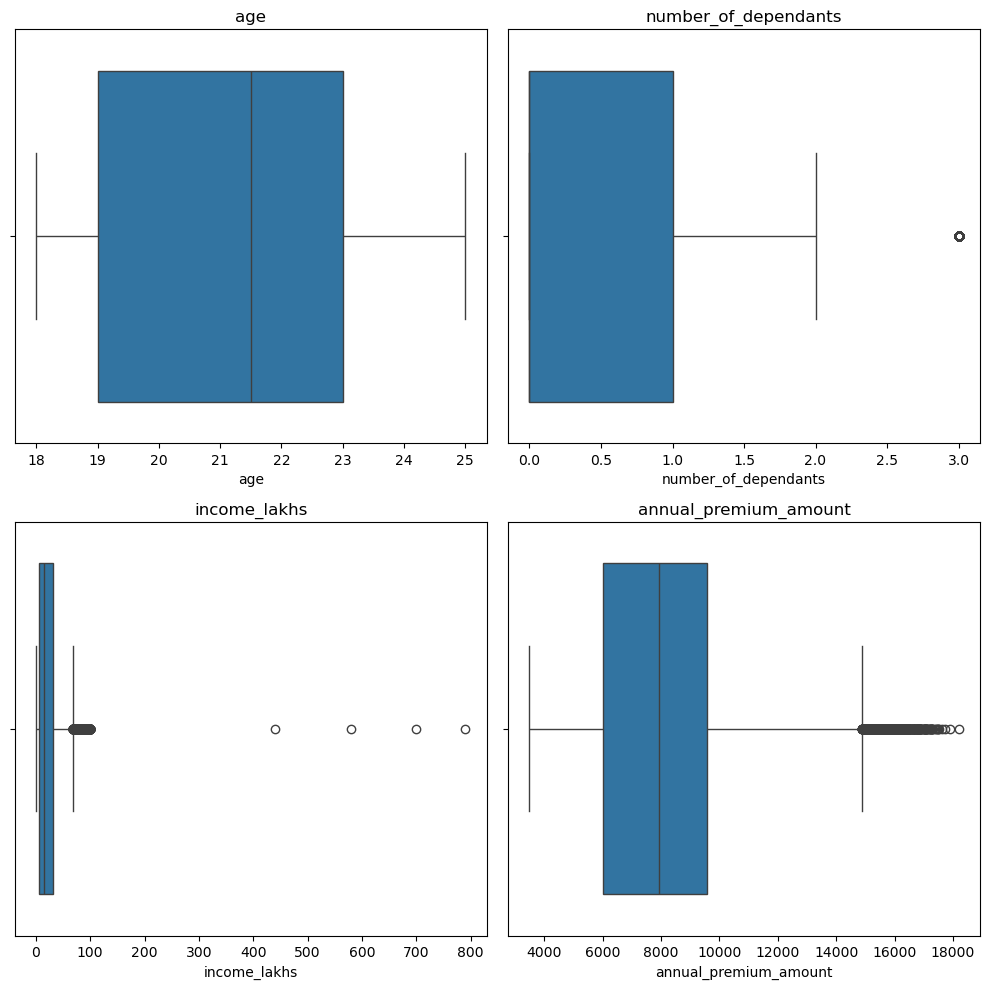

In [20]:
num_plots = len(numerical_columns)
num_cols = 2  
num_rows = (num_plots + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 5 * num_rows))  # Adjust the figure size as needed
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col) 

for j in range(i + 1, num_rows * num_cols):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

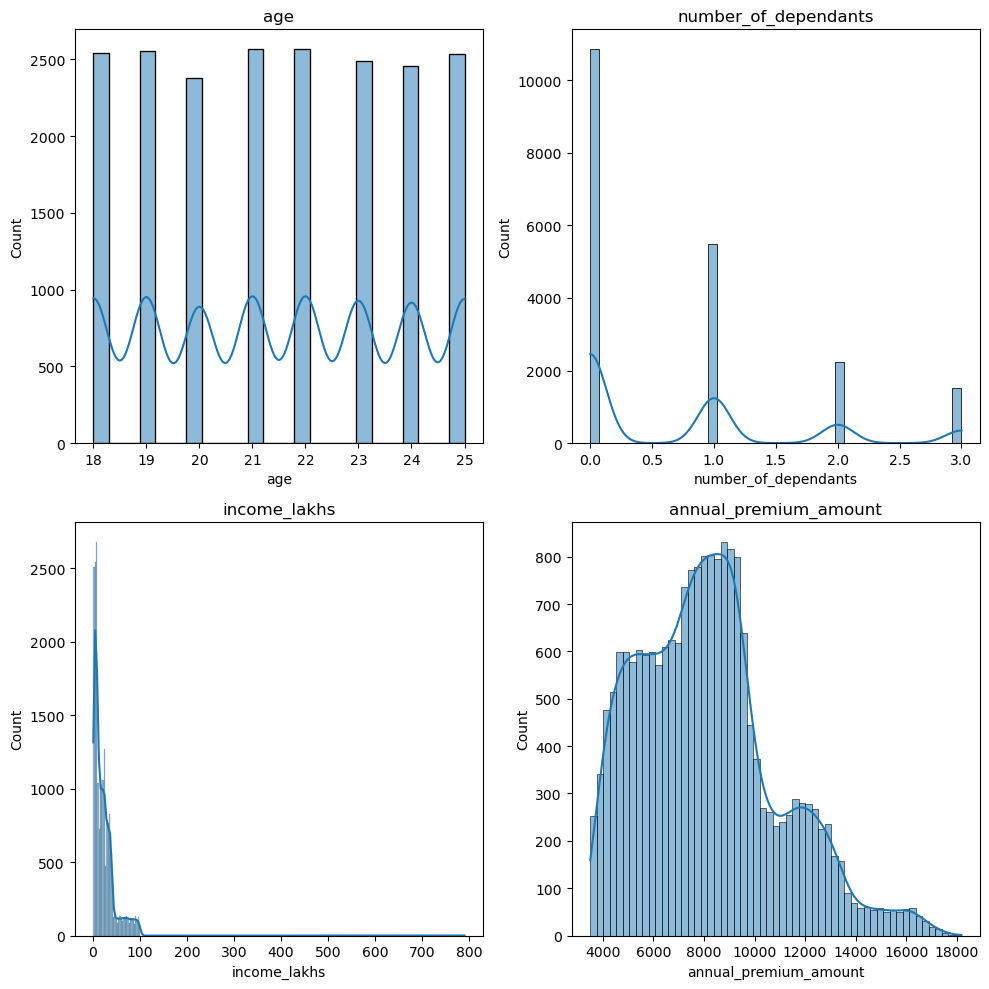

In [21]:
num_plots = len(numerical_columns)
num_cols = 2
num_rows = (num_plots + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 5 * num_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    sns.histplot(df[col], ax=axes[i], kde=True)
    axes[i].set_title(col) 

for j in range(i + 1, num_rows * num_cols):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [22]:
df[df["age"]>100].shape

(0, 13)

In [23]:
df[df["age"]>100]["age"].unique()

array([], dtype=int64)

In [24]:
df1 = df[df["age"]<100]
df1["age"].describe()

count    20096.000000
mean        21.494029
std          2.294050
min         18.000000
25%         19.000000
50%         21.500000
75%         23.000000
max         25.000000
Name: age, dtype: float64

In [25]:
Q1 = df1["income_lakhs"].quantile(0.25)
Q3 = df1["income_lakhs"].quantile(0.75)
IQR = Q3-Q1
upper_range = Q3 + 1.5*IQR
lower_range = Q1 - 1.5*IQR
print(upper_range, lower_range)

68.5 -31.5


67 lakhs is a normal income in india, so we will drop the records where the values exceed the range of 0.999 quantile

In [26]:
df1[df1["income_lakhs"]> upper_range].shape

(1295, 13)

In [27]:
df1[df1["income_lakhs"]> upper_range]["income_lakhs"].unique()

array([ 99,  97,  70,  92,  90,  88,  86,  98,  80,  81,  85,  78,  75,
        84,  71,  73,  95,  69,  89,  72,  93,  91,  82,  96,  74,  79,
        77,  76, 100,  87,  83,  94, 440, 580, 700, 790])

In [28]:
threshold_quantile = df1["income_lakhs"].quantile(0.999)
threshold_quantile

np.float64(100.0)

In [29]:
df1[df1["income_lakhs"]>threshold_quantile]["income_lakhs"].shape

(4,)

In [30]:
df2 = df1[df1["income_lakhs"] <= threshold_quantile]
df2.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,No Disease,Bronze,5684
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,No Disease,Bronze,5712


In [31]:
df2.shape

(20092, 13)

<Axes: xlabel='income_lakhs', ylabel='Count'>

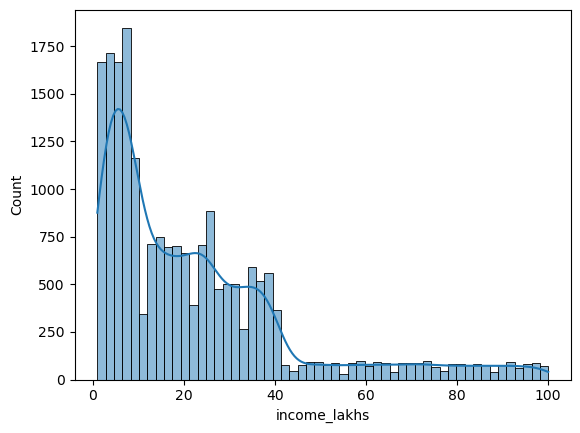

In [32]:
sns.histplot(data = df2, x ="income_lakhs", kde = True)

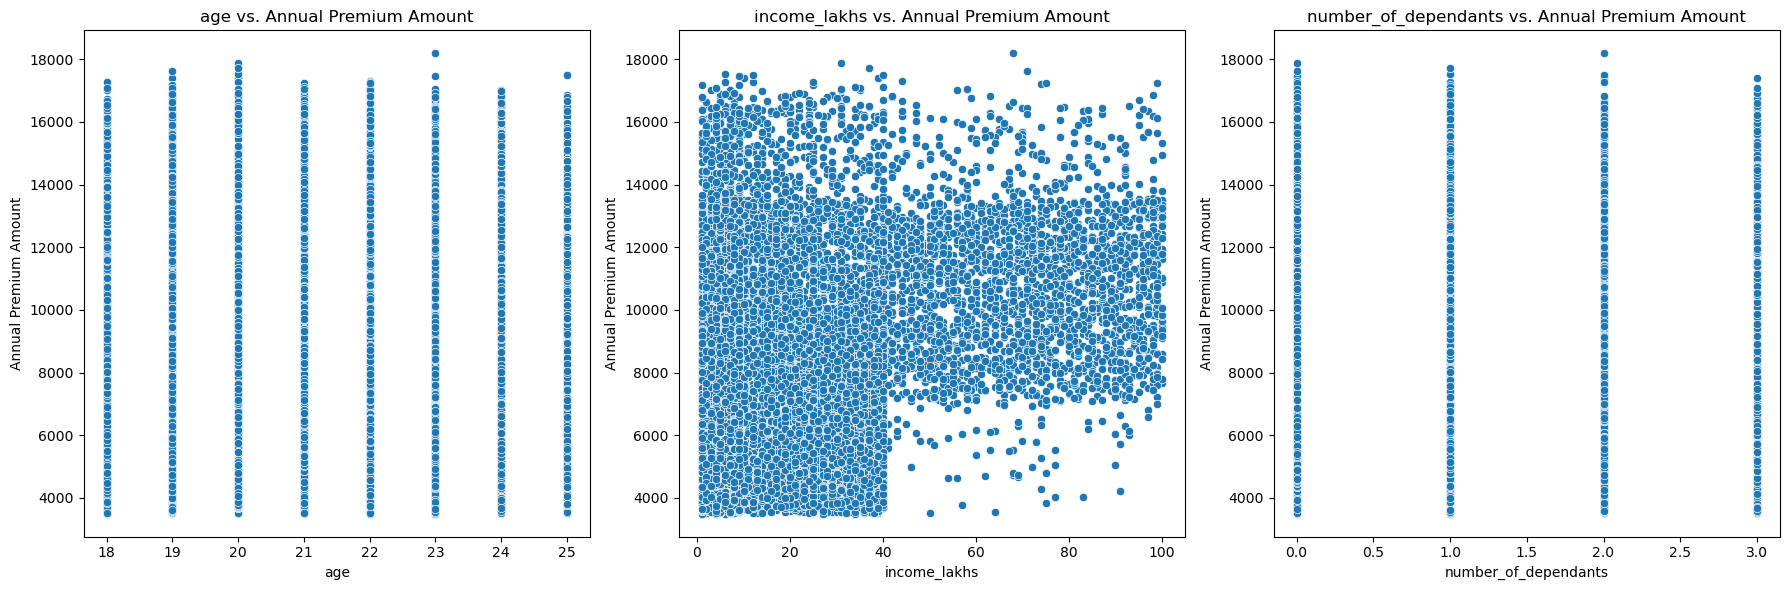

In [33]:
numeric_features = ['age', 'income_lakhs', 'number_of_dependants']

fig, axes = plt.subplots(1, len(numeric_features), figsize=(18, 6)) 

for ax, column in zip(axes, numeric_features):
    sns.scatterplot(x=df2[column], y=df2['annual_premium_amount'], ax=ax)
    ax.set_title(f'{column} vs. Annual Premium Amount')
    ax.set_xlabel(column)
    ax.set_ylabel('Annual Premium Amount')

plt.tight_layout() 
plt.show()

#### 2.Categorical column

In [34]:
Categorical_columns = df2.select_dtypes(["object"]).columns
Categorical_columns

Index(['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status',
       'employment_status', 'income_level', 'medical_history',
       'insurance_plan'],
      dtype='object')

In [35]:
for col in Categorical_columns:
    print(col, ":", df2[col].unique())

gender : ['Male' 'Female']
region : ['Northeast' 'Northwest' 'Southeast' 'Southwest']
marital_status : ['Unmarried' 'Married']
bmi_category : ['Overweight' 'Underweight' 'Normal' 'Obesity']
smoking_status : ['Regular' 'No Smoking' 'Occasional' 'Smoking=0' 'Does Not Smoke'
 'Not Smoking']
employment_status : ['Self-Employed' 'Freelancer' 'Salaried' nan]
income_level : ['> 40L' '<10L' '10L - 25L' '25L - 40L']
medical_history : ['High blood pressure' 'No Disease' 'Diabetes & High blood pressure'
 'Diabetes & Heart disease' 'Diabetes' 'Diabetes & Thyroid'
 'Heart disease' 'Thyroid' 'High blood pressure & Heart disease']
insurance_plan : ['Silver' 'Bronze' 'Gold']


In [36]:
df2['smoking_status'].replace({
    'Not Smoking': 'No Smoking',
    'Does Not Smoke': 'No Smoking',
    'Smoking=0': 'No Smoking'
}, inplace=True)

df2['smoking_status'].unique()

C:\Users\Sarthak\AppData\Local\Temp\ipykernel_21708\263445883.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2['smoking_status'].replace({
C:\Users\Sarthak\AppData\Local\Temp\ipykernel_21708\263445883.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['smoking_status'].replace({


array(['Regular', 'No Smoking', 'Occasional'], dtype=object)

In [37]:
df2["smoking_status"].unique()

array(['Regular', 'No Smoking', 'Occasional'], dtype=object)

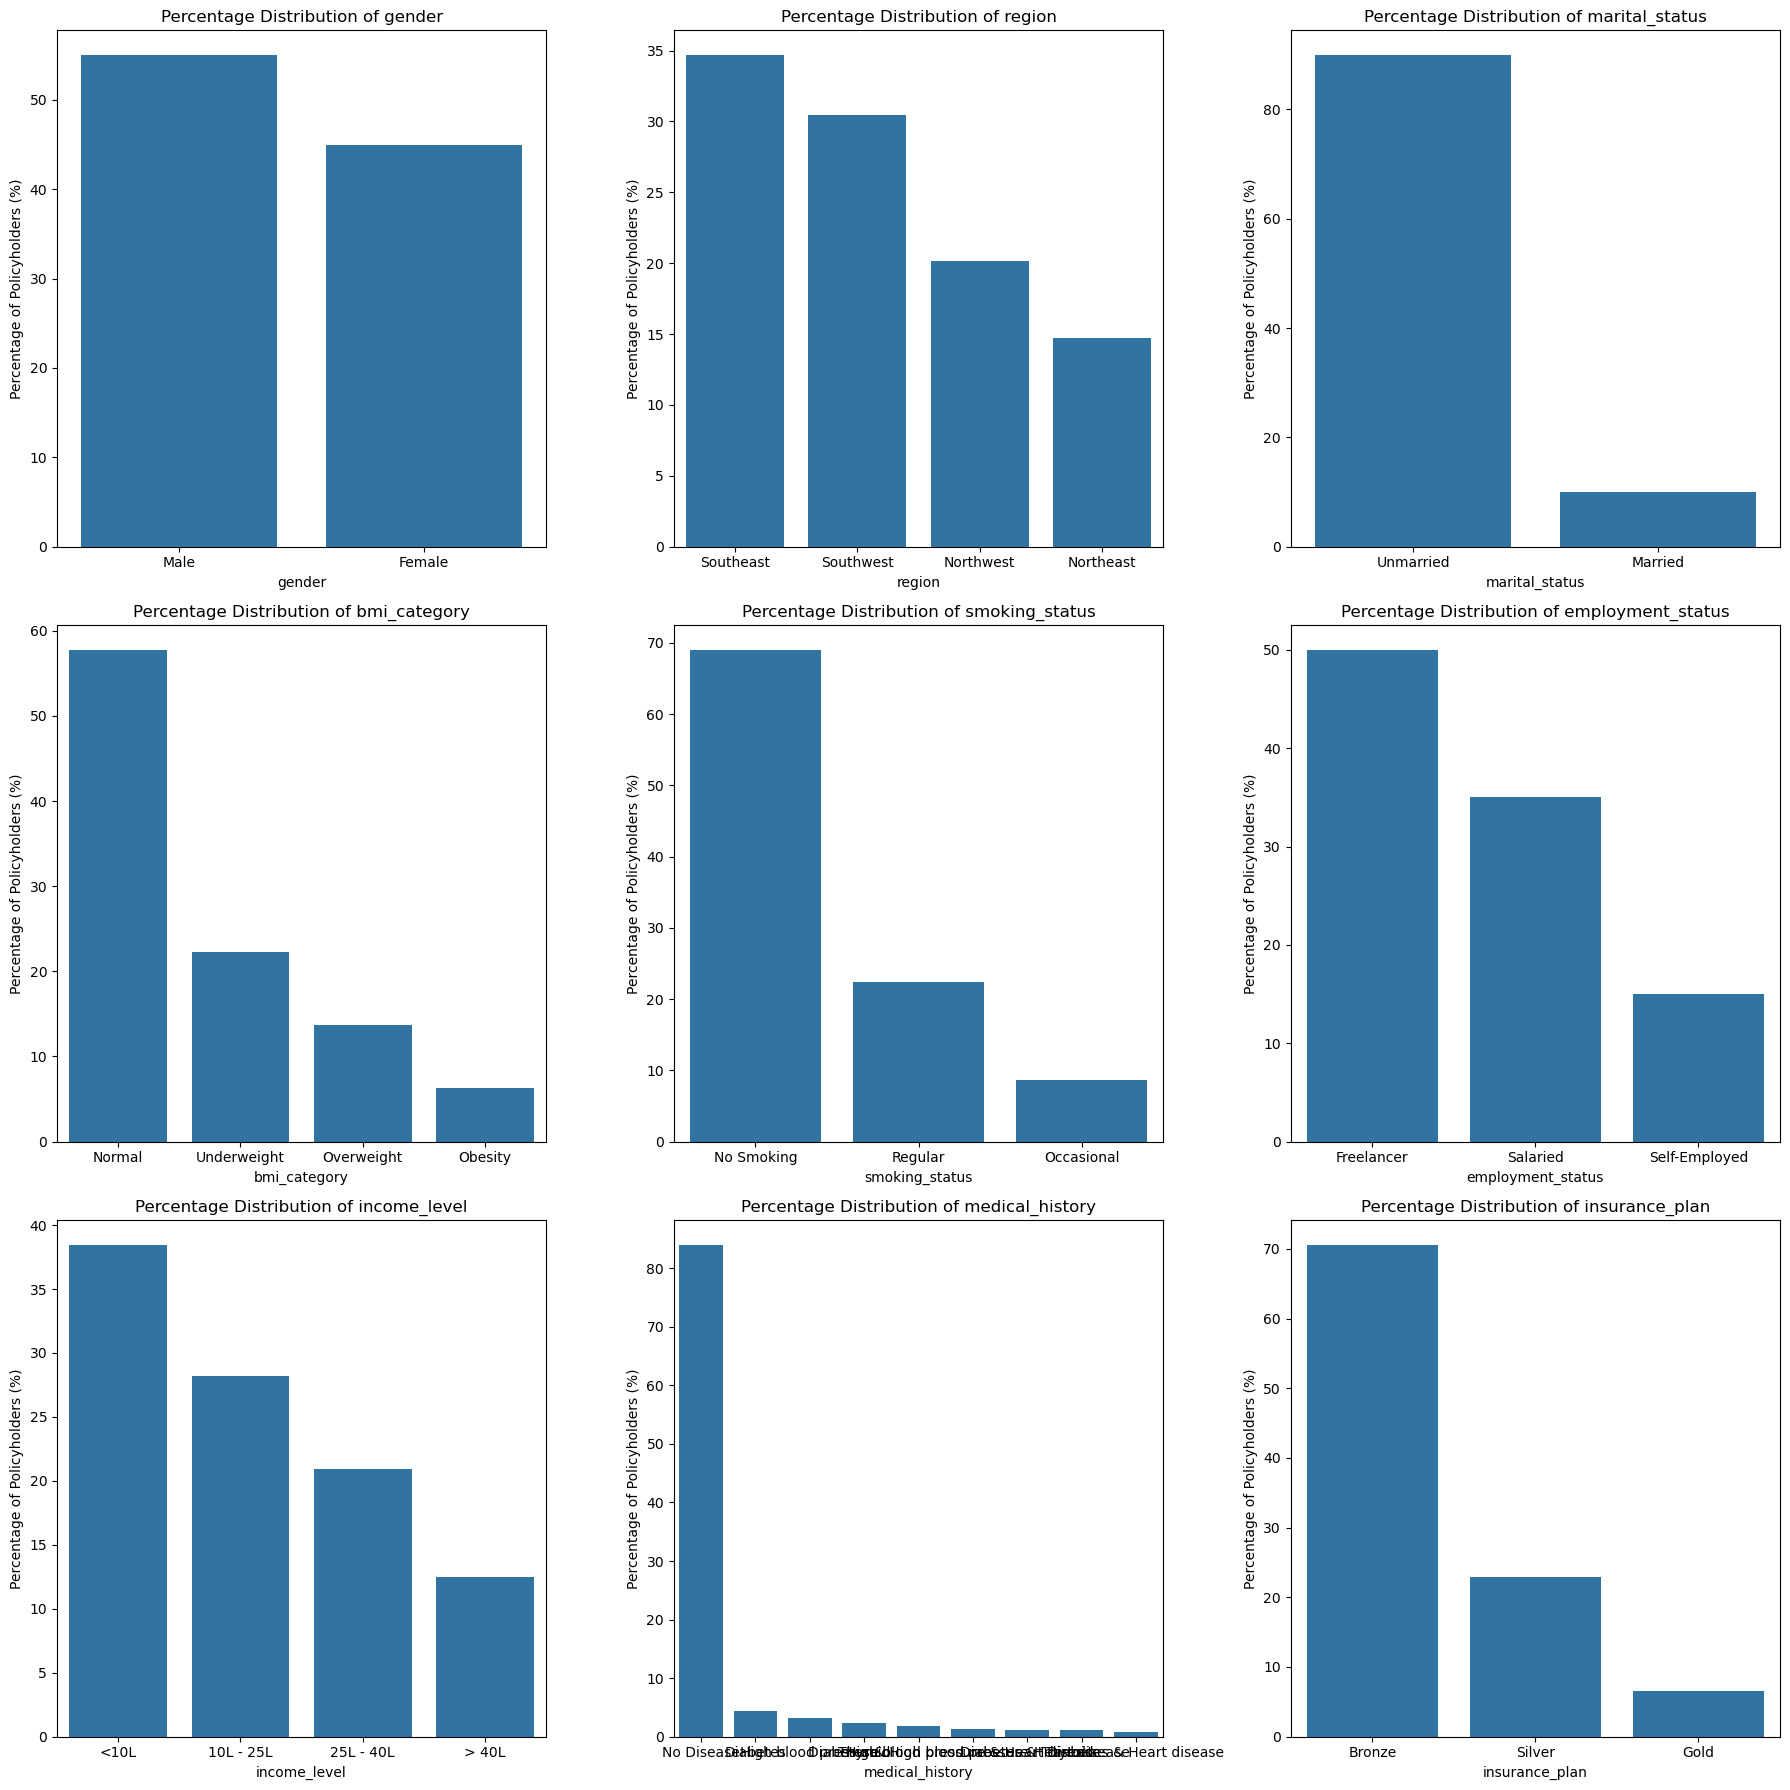

In [38]:
fig, axes = plt.subplots(3, 3, figsize=(18, 18))  
axes = axes.flatten()  

for ax, column in zip(axes, Categorical_columns):
    # Calculate the percentage distribution of each category
    category_counts = df2[column].value_counts(normalize=True) * 100  # normalize=True gives the relative frequencies
    
    # Plotting the distribution using barplot
    sns.barplot(x=category_counts.index, y=category_counts.values, ax=ax)
    ax.set_title(f'Percentage Distribution of {column}')
    ax.set_ylabel('Percentage of Policyholders (%)')
    ax.set_xlabel(column)  # Set xlabel to the column name for clarity

plt.tight_layout()  # Adjusts plot parameters for better fit in the figure window
plt.show()

insurance_plan  Bronze  Gold  Silver
income_level                        
10L - 25L         4509   326     828
25L - 40L         3382   209     608
<10L              6175   404    1147
> 40L              115   366    2023


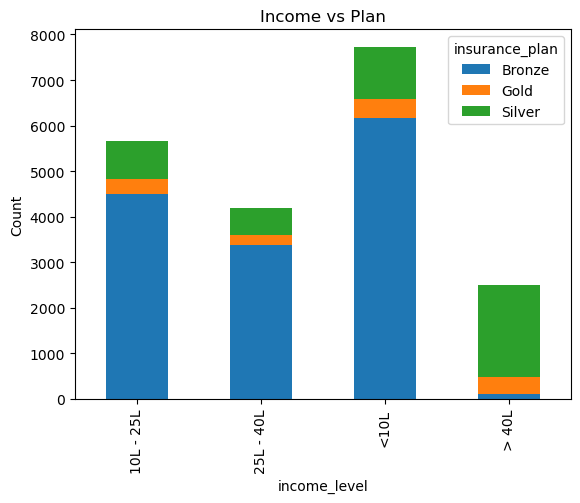

In [39]:
crosstab = pd.crosstab(df2['income_level'], df2['insurance_plan'])
print(crosstab)

crosstab.plot(kind='bar', stacked=True)
plt.title('Income vs Plan')
plt.ylabel('Count')
plt.show()

Most of the people which less than 10 lakh income have bronze tier of insurance plan

<h2 align="center" style="color:blue">Feature Engineering</h2>

In [40]:
df2.head(3)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857


In [41]:
df2["medical_history"].unique()

array(['High blood pressure', 'No Disease',
       'Diabetes & High blood pressure', 'Diabetes & Heart disease',
       'Diabetes', 'Diabetes & Thyroid', 'Heart disease', 'Thyroid',
       'High blood pressure & Heart disease'], dtype=object)

##### Assigning some score to each disease based on domain understanding

In [42]:
risk_scores = {
    "diabetes": 6,
    "heart disease": 8,
    "high blood pressure":6,
    "thyroid": 5,
    "no disease": 0,
    "none":0
}

In [43]:
df2[['disease1', 'disease2']] = df2['medical_history'].str.split(" & ", expand=True).apply(lambda x: x.str.lower())
df2['disease1'].fillna('none', inplace=True)
df2['disease2'].fillna('none', inplace=True)

C:\Users\Sarthak\AppData\Local\Temp\ipykernel_21708\2811996713.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2[['disease1', 'disease2']] = df2['medical_history'].str.split(" & ", expand=True).apply(lambda x: x.str.lower())
C:\Users\Sarthak\AppData\Local\Temp\ipykernel_21708\2811996713.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2[['disease1', 'disease2']] = df2['medical_history'].str.split(" & ", expand=True).apply(lambda x: x.str.lower())
C:\Users\Sarthak\AppData\Local\Temp\ipykernel_2170

In [44]:
df2.head(2)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,high blood pressure,none
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050,no disease,none


### calculating risk scores

In [45]:
df2['total_risk_score'] = 0
for disease in ['disease1', 'disease2']:
    df2['total_risk_score'] += df2[disease].map(risk_scores)

max_score = df2['total_risk_score'].max()
min_score = df2['total_risk_score'].min()
df2['normalized_risk_score'] = (df2['total_risk_score'] - min_score) / (max_score - min_score)
df2.head(2)

C:\Users\Sarthak\AppData\Local\Temp\ipykernel_21708\3931687836.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['total_risk_score'] = 0
C:\Users\Sarthak\AppData\Local\Temp\ipykernel_21708\3931687836.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['total_risk_score'] += df2[disease].map(risk_scores)
C:\Users\Sarthak\AppData\Local\Temp\ipykernel_21708\3931687836.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_index

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,normalized_risk_score
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,high blood pressure,none,6,0.428571
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050,no disease,none,0,0.000000


In [46]:
df3 = df2.drop(["medical_history", "disease1", "disease2", "total_risk_score"], axis=1)
df3.head(2)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,insurance_plan,annual_premium_amount,normalized_risk_score
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,Silver,13365,0.428571
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,Silver,11050,0.000000


#### Label Encoding for ordinal columns

In [47]:
df3['insurance_plan'] = df3['insurance_plan'].map({'Bronze': 1, 'Silver': 2, 'Gold': 3})

In [48]:
df3["income_level"].unique()

array(['> 40L', '<10L', '10L - 25L', '25L - 40L'], dtype=object)

In [49]:
df3['income_level'] = df3['income_level'].map({'<10L':1, '10L - 25L': 2, '25L - 40L':3, '> 40L':4})
df3.sample(5)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,insurance_plan,annual_premium_amount,normalized_risk_score
5878,19,Male,Northeast,Unmarried,1,Underweight,No Smoking,Salaried,2,11,1,4066,0.0
6704,23,Female,Southwest,Unmarried,0,Normal,Regular,Salaried,1,5,1,4243,0.0
1455,25,Male,Northwest,Unmarried,0,Normal,Occasional,Salaried,3,32,1,8024,0.0
1289,20,Female,Northwest,Unmarried,1,Underweight,No Smoking,Self-Employed,2,24,1,5735,0.0
10541,19,Male,Southeast,Unmarried,1,Normal,No Smoking,Freelancer,1,4,2,12806,0.0


In [50]:
cat_columns2 = df3.select_dtypes(["object"]).columns
cat_columns2

Index(['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status',
       'employment_status'],
      dtype='object')

In [51]:
for col in cat_columns2:
    print(f"{col} : {df3[col].unique()}")

gender : ['Male' 'Female']
region : ['Northeast' 'Northwest' 'Southeast' 'Southwest']
marital_status : ['Unmarried' 'Married']
bmi_category : ['Overweight' 'Underweight' 'Normal' 'Obesity']
smoking_status : ['Regular' 'No Smoking' 'Occasional']
employment_status : ['Self-Employed' 'Freelancer' 'Salaried' nan]


#### one hot encoding for nominal columns

In [52]:
df4 = pd.get_dummies(df3, columns=cat_columns2, drop_first=True, dtype=int)
df4.head(3)

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,18,0,4,99,2,13365,0.428571,1,0,0,0,1,0,1,0,0,1,0,1
1,22,0,1,3,2,11050,0.000000,0,1,0,0,1,0,0,1,0,0,0,0
2,21,0,4,97,2,11857,0.000000,0,0,1,0,1,0,0,0,0,1,1,0


In [53]:
df4.columns

Index(['age', 'number_of_dependants', 'income_level', 'income_lakhs',
       'insurance_plan', 'annual_premium_amount', 'normalized_risk_score',
       'gender_Male', 'region_Northwest', 'region_Southeast',
       'region_Southwest', 'marital_status_Unmarried', 'bmi_category_Obesity',
       'bmi_category_Overweight', 'bmi_category_Underweight',
       'smoking_status_Occasional', 'smoking_status_Regular',
       'employment_status_Salaried', 'employment_status_Self-Employed'],
      dtype='object')

In [54]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20092 entries, 0 to 20095
Data columns (total 19 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              20092 non-null  int64  
 1   number_of_dependants             20092 non-null  int64  
 2   income_level                     20092 non-null  int64  
 3   income_lakhs                     20092 non-null  int64  
 4   insurance_plan                   20092 non-null  int64  
 5   annual_premium_amount            20092 non-null  int64  
 6   normalized_risk_score            20092 non-null  float64
 7   gender_Male                      20092 non-null  int64  
 8   region_Northwest                 20092 non-null  int64  
 9   region_Southeast                 20092 non-null  int64  
 10  region_Southwest                 20092 non-null  int64  
 11  marital_status_Unmarried         20092 non-null  int64  
 12  bmi_category_Obesity   

### Calculating VIF to measure multicollinearity

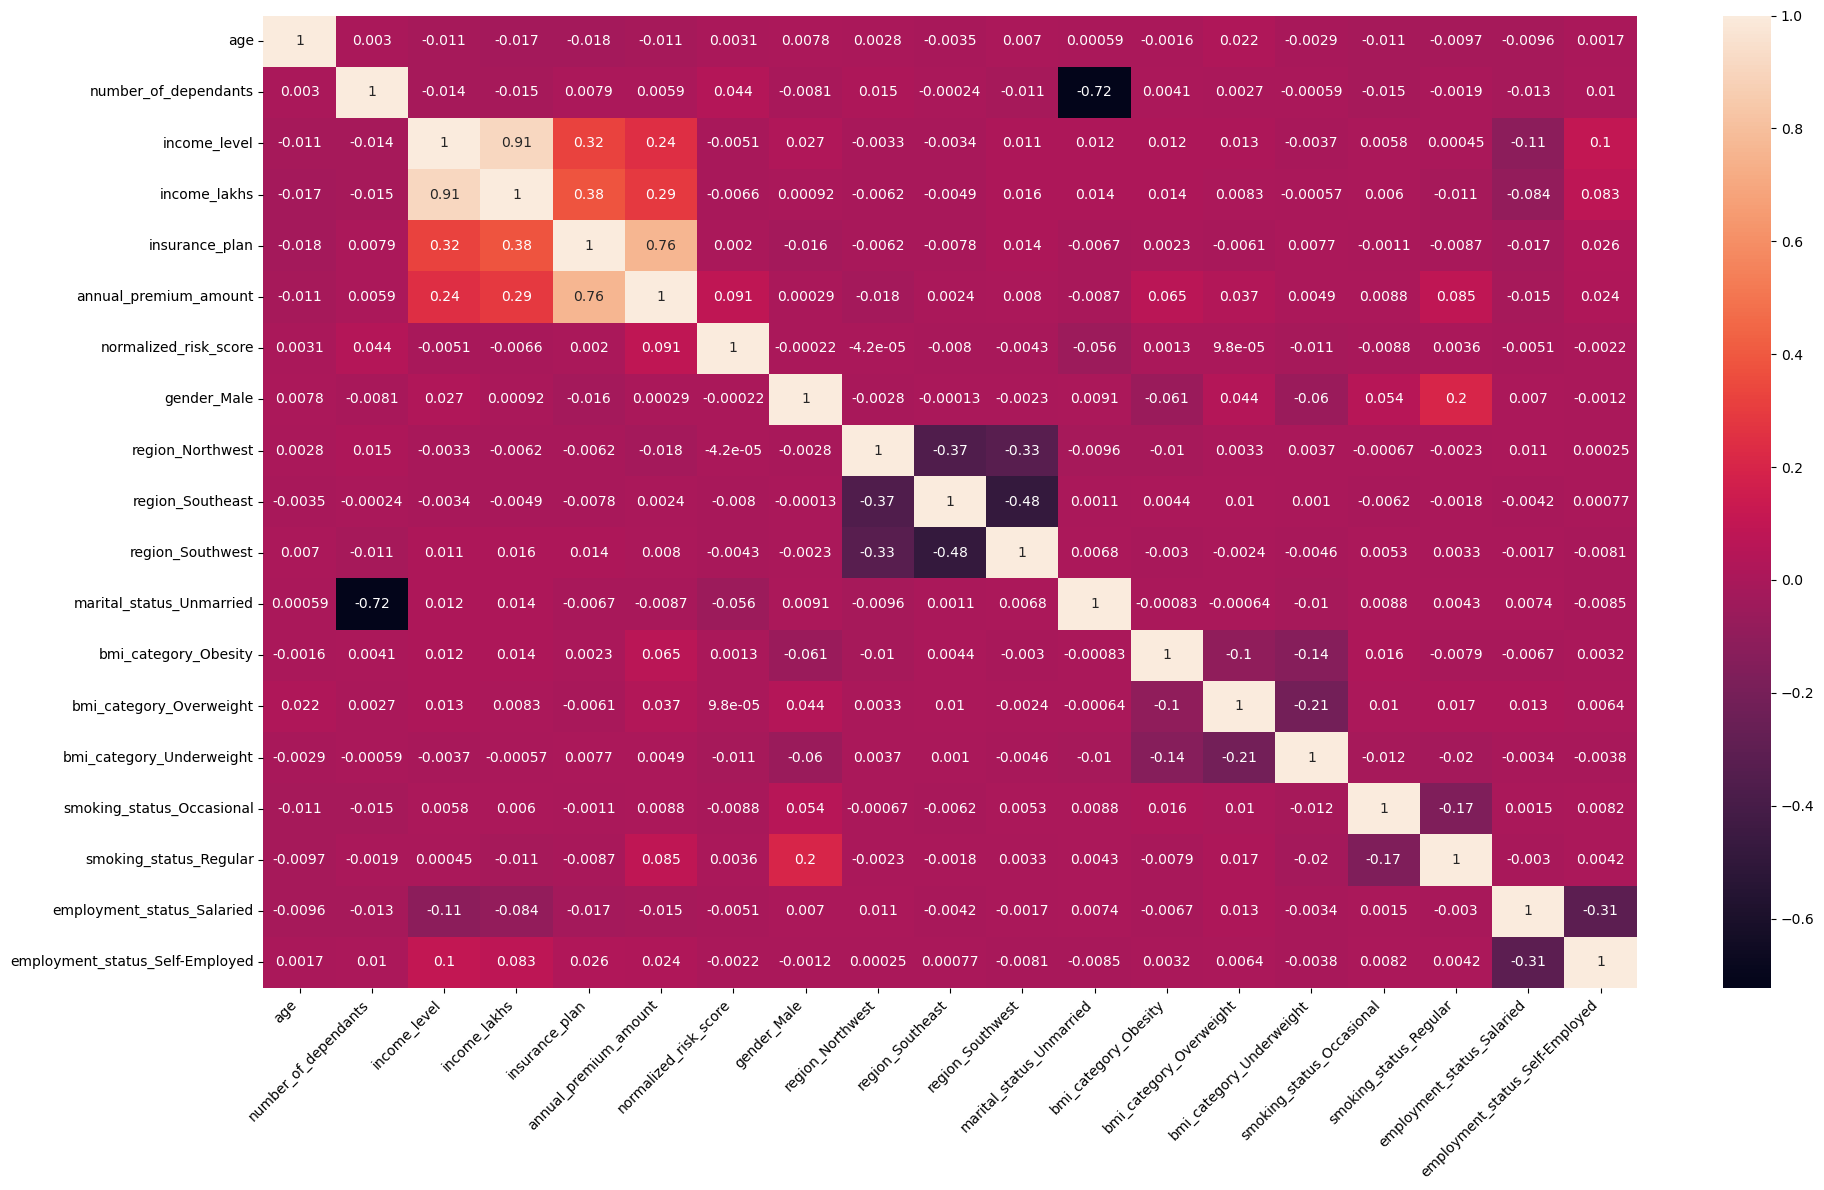

In [55]:
cm = df4.corr()

plt.figure(figsize=(20,12))
sns.heatmap(cm, annot=True)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### scaling columns using min max scalar

In [56]:
df4.sample(6)

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
5219,18,1,2,17,1,4891,0.357143,1,0,0,0,1,0,0,0,0,1,0,0
9676,25,0,3,38,1,8103,0.000000,1,0,0,0,1,0,0,1,0,0,0,0
19005,24,2,2,10,1,5300,0.000000,1,1,0,0,1,0,0,0,0,0,0,0
15909,18,3,2,13,1,4033,0.000000,0,0,1,0,0,0,0,0,0,0,0,0
18463,22,0,1,7,1,10098,0.000000,1,0,0,1,1,0,1,0,1,0,0,0
9840,18,1,1,7,1,9049,0.000000,1,0,0,1,1,0,1,0,0,0,0,0


In [57]:
X = df4.drop('annual_premium_amount', axis='columns')
y = df4['annual_premium_amount']

from sklearn.preprocessing import MinMaxScaler

cols_to_scale = ['age','number_of_dependants', 'income_level',  'income_lakhs', 'insurance_plan']
scaler = MinMaxScaler()

X[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])
X.describe()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
count,20092.000000,20092.000000,20092.000000,20092.000000,20092.000000,20092.000000,20092.000000,20092.000000,20092.000000,20092.000000,20092.000000,20092.000000,20092.000000,20092.000000,20092.000000,20092.000000,20092.000000,20092.000000
mean,0.499161,0.240908,0.357904,0.216021,0.179574,0.092048,0.550368,0.201224,0.346954,0.304649,0.899861,0.063508,0.136522,0.222477,0.086452,0.223522,0.350040,0.149960
std,0.327749,0.312431,0.347475,0.219501,0.300034,0.229987,0.497469,0.400925,0.476013,0.460270,0.300193,0.243880,0.343351,0.415920,0.281038,0.416615,0.476994,0.357041
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.142857,0.000000,0.000000,0.050505,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.571429,0.000000,0.333333,0.151515,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.714286,0.333333,0.666667,0.303030,0.500000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [58]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df['Column'] = data.columns
    vif_df['VIF'] = [variance_inflation_factor(data.values,i) for i in range(data.shape[1])]
    return vif_df

In [59]:
calculate_vif(X)

,Column,VIF
0,age,3.142768
1,number_of_dependants,1.860865
2,income_level,11.927347
3,income_lakhs,11.874116
4,insurance_plan,1.592797
5,normalized_risk_score,1.154183
6,gender_Male,2.310045
7,region_Northwest,2.147417
8,region_Southeast,2.970147
9,region_Southwest,2.730727


##### dropping columns one by one

In [60]:
calculate_vif(X.drop('income_level', axis="columns"))

,Column,VIF
0,age,3.141417
1,number_of_dependants,1.858222
2,income_lakhs,2.291399
3,insurance_plan,1.587690
4,normalized_risk_score,1.154134
5,gender_Male,2.299869
6,region_Northwest,2.146486
7,region_Southeast,2.968962
8,region_Southwest,2.730051
9,marital_status_Unmarried,7.299638


In [61]:
X_reduced = X.drop('income_level', axis="columns")

<h2 align="center" style="color:blue">Model Training</h2>

#### Attempt 1:
using linear regression, ridge regression, xgboost

### Linear Regression

In [62]:
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.30, random_state=10)

# shape of the X_train, X_test, y_train, y_test features
print("x train: ",X_train.shape)
print("x test: ",X_test.shape)
print("y train: ",y_train.shape)
print("y test: ",y_test.shape)

x train:  (14064, 17)
x test:  (6028, 17)
y train:  (14064,)
y test:  (6028,)


In [63]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
test_score = model_lr.score(X_test, y_test)
train_score = model_lr.score(X_train, y_train)
train_score, test_score

(0.6009197044079231, 0.6071056945055624)

In [64]:
y_pred = model_lr.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred)
r2_lr = r2_score(y_test, y_pred)
rmse_lr = np.sqrt(mse_lr)
print("Linear Regression ==> MSE: ", mse_lr, "RMSE: ", rmse_lr, "R2_score: ", r2_lr)

Linear Regression ==> MSE:  3053899.80990426 RMSE:  1747.5410753124688 R2_score:  0.6071056945055624


In [65]:
np.set_printoptions(suppress=True, precision=6)
model_lr.coef_

array([  44.132329, -124.440831,  -47.260846, 7000.065349, 1019.592419,
        -20.359954, -120.450796,   -1.152712,  -45.233714,  -91.629445,
        798.597604,  392.301798,  154.90245 ,  246.270651,  587.402229,
         11.213318,   18.908299])

In [66]:
feature_importance = model_lr.coef_

coef_df = pd.DataFrame(feature_importance, index=X_train.columns, columns=['Coefficients'])
coef_df

,Coefficients
age,44.132329
number_of_dependants,-124.440831
income_lakhs,-47.260846
insurance_plan,7000.065349
normalized_risk_score,1019.592419
gender_Male,-20.359954
region_Northwest,-120.450796
region_Southeast,-1.152712
region_Southwest,-45.233714
marital_status_Unmarried,-91.629445


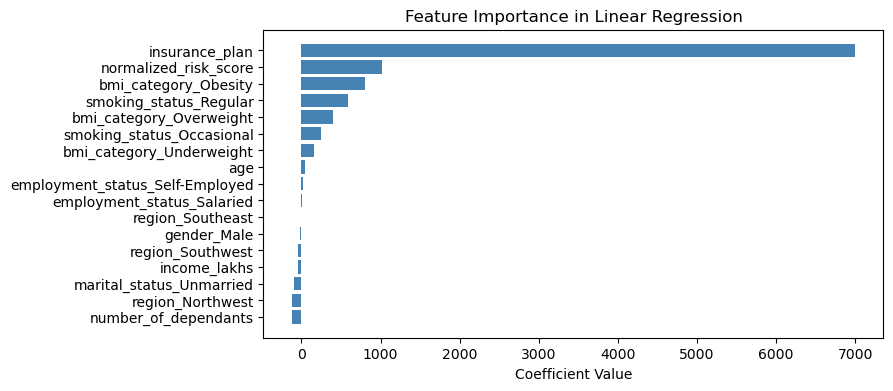

In [67]:
coef_df = coef_df.sort_values(by='Coefficients', ascending=True)


plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in Linear Regression')
plt.show()

### Ridge Regression 

In [68]:
model_rg = Ridge(alpha=1)
model_rg.fit(X_train, y_train)
test_score = model_rg.score(X_test, y_test)
train_score = model_rg.score(X_train, y_train)
train_score, test_score

(0.6009192370590892, 0.6071104089786603)

In [69]:
y_pred = model_rg.predict(X_test)

mse_rl = mean_squared_error(y_test, y_pred)
r2_rl = r2_score(y_test, y_pred)
rmse_rl = np.sqrt(mse_lr)
print("Ridge Regression ==> MSE: ", mse_rl, "RMSE: ", rmse_rl, "r2_score: ", r2_rl)

Ridge Regression ==> MSE:  3053863.165116346 RMSE:  1747.5410753124688 r2_score:  0.6071104089786603


### XG Boost

In [70]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor(n_estimators=20, max_depth=3)
model_xgb.fit(X_train, y_train)
model_xgb.score(X_test, y_test)

0.6054363250732422

In [71]:
y_pred = model_xgb.predict(X_test)

mse_xgb = mean_squared_error(y_test, y_pred)
rmse_xgb = np.sqrt(mse_lr)
print("XGBoost Regression ==> MSE: ", mse_xgb, "RMSE: ", rmse_xgb)

XGBoost Regression ==> MSE:  3066875.5 RMSE:  1747.5410753124688


### Attempt 2:
using randomizedcv
using xgboost

In [72]:
model_xgb = XGBRegressor()
param_grid = {
    'n_estimators': [20, 40, 50],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
}
random_search = RandomizedSearchCV(model_xgb, param_grid, n_iter=10, cv=3, scoring='r2', random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)
random_search.best_score_

y_pred = random_search.predict(X_test)

mse_xgb_rcv = mean_squared_error(y_test, y_pred)
rmse_xgb_rcv = np.sqrt(mse_lr)
print("XGBoost Regression ==> MSE: ", mse_lr, "RMSE: ", rmse_lr)

XGBoost Regression ==> MSE:  3053899.80990426 RMSE:  1747.5410753124688


In [73]:
random_search.best_params_

{'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.1}

In [74]:
best_model = random_search.best_estimator_

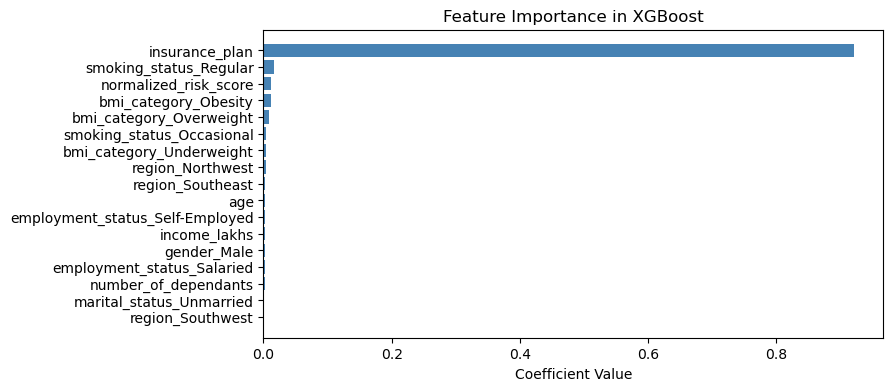

In [75]:
feature_importance = best_model.feature_importances_

coef_df = pd.DataFrame(feature_importance, index=X_train.columns, columns=['Coefficients'])

coef_df = coef_df.sort_values(by='Coefficients', ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in XGBoost')
plt.show()

### Attempt 3:
1. using XG boost
2. using cross validation
3. Parameter tuning using optuna
4. Using early stopping for computational resources

In [76]:
import optuna


class EarlyStoppingCallback:
    def __init__(self, patience=4, min_trials=10):
        self.patience = patience      
        self.min_trials = min_trials  

    def __call__(self, study, trial):
        if trial.number + 1 < self.min_trials:
            return
        trials_since_best = trial.number - study.best_trial.number
        if trials_since_best >= self.patience:
            print(f"Early stopping at trial {trial.number}: no improvement in "
                  f"{self.patience} trials after best trial {study.best_trial.number}.")
            study.stop()

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
        "random_state": 42,
    }
    model = XGBRegressor(**params, max_iter=10000)
    scores = cross_val_score(model, X_train, y_train, cv=3,
                             scoring="neg_root_mean_squared_error", n_jobs=-1)
    return -scores.mean()  

study_xgb = optuna.create_study(direction="minimize")
study_xgb.optimize(
    objective,
    n_trials=50,                                             
    callbacks=[EarlyStoppingCallback(patience=4, min_trials=10)],
)

# ---- Best result ----
print("Best trial number:", study_xgb.best_trial.number)
print("Best CV RMSE:", study_xgb.best_value)
print("Best params:", study_xgb.best_params)

best_model_XGR = XGBRegressor(**study_xgb.best_params, max_iter=10000)
best_model_XGR.fit(X_train, y_train)

y_pred = best_model_XGR.predict(X_test)
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Test MAE:", mean_absolute_error(y_test, y_pred))
print("Test R2:", r2_score(y_test, y_pred))

[I 2026-10-05 00:33:36,487] A new study created in memory with name: no-name-07236f6c-4e37-45fb-8e6a-f62a1ee831da
[I 2026-10-05 00:33:41,101] Trial 0 finished with value: 1795.8011881510417 and parameters: {'n_estimators': 993, 'learning_rate': 0.010911863601658831, 'max_depth': 9, 'min_child_weight': 2, 'subsample': 0.5373022460189816, 'colsample_bytree': 0.6230878142491048, 'reg_lambda': 0.9197247992570284}. Best is trial 0 with value: 1795.8011881510417.
[I 2026-10-05 00:33:44,679] Trial 1 finished with value: 2009.2500813802083 and parameters: {'n_estimators': 754, 'learning_rate': 0.054542674621736335, 'max_depth': 10, 'min_child_weight': 8, 'subsample': 0.568179862287288, 'colsample_bytree': 0.9753469044053729, 'reg_lambda': 0.035725779194716006}. Best is trial 0 with value: 1795.8011881510417.
[I 2026-10-05 00:33:47,437] Trial 2 finished with value: 1811.855712890625 and parameters: {'n_estimators': 1182, 'learning_rate': 0.062198363310190734, 'max_depth': 5, 'min_child_weight':

Early stopping at trial 10: no improvement in 4 trials after best trial 6.
Best trial number: 6
Best CV RMSE: 1757.8575439453125
Best params: {'n_estimators': 599, 'learning_rate': 0.03138210199673253, 'max_depth': 5, 'min_child_weight': 7, 'subsample': 0.734173492657952, 'colsample_bytree': 0.863361348127403, 'reg_lambda': 1.61886805412736}
Test RMSE: 1772.0591835489017
Test MAE: 1525.648681640625
Test R2: 0.5960037112236023


98% R2 score doesn't mean our model is performing really good

### Error analysis

In [77]:
y_pred = best_model_XGR.predict(X_test)

residuals = y_pred - y_test
residuals_pct = (residuals / y_test) * 100

results_df = pd.DataFrame({
    'actual': y_test, 
    'predicted': y_pred, 
    'diff': residuals, 
    'diff_pct': residuals_pct
})
results_df.head()

,actual,predicted,diff,diff_pct
8470,4536,6922.945312,2386.945312,52.622251
18712,7940,6750.831055,-1189.168945,-14.976939
19719,14935,14002.784180,-932.215820,-6.241820
17956,9818,10828.446289,1010.446289,10.291773
7393,3900,6811.169922,2911.169922,74.645383


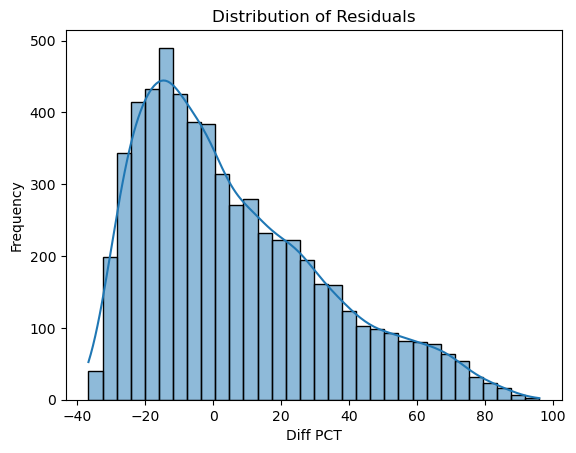

In [78]:
sns.histplot(results_df['diff_pct'], kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Diff PCT')
plt.ylabel('Frequency')
plt.show()

In [79]:
X_test.shape

(6028, 17)

In [80]:
extreme_error_threshold = 10
extreme_results_df = results_df[np.abs(results_df['diff_pct']) > extreme_error_threshold]
extreme_results_df.head()

,actual,predicted,diff,diff_pct
8470,4536,6922.945312,2386.945312,52.622251
18712,7940,6750.831055,-1189.168945,-14.976939
17956,9818,10828.446289,1010.446289,10.291773
7393,3900,6811.169922,2911.169922,74.645383
17923,5843,6724.565918,881.565918,15.087556


In [81]:
extreme_results_df.shape

(4365, 4)

In [82]:
extreme_errors_pct = extreme_results_df.shape[0]*100/X_test.shape[0]
extreme_errors_pct

72.41207697412077

29% extreme error mean the 29% customers were either overcharge or undercharged by 10%.

In [83]:
extreme_results_df[abs(extreme_results_df.diff_pct)>50].sort_values("diff_pct",ascending=False)

,actual,predicted,diff,diff_pct
12006,3522,6903.725098,3381.725098,96.017181
5028,3582,6924.479004,3342.479004,93.313205
18500,3508,6722.285645,3214.285645,91.627299
11884,3546,6723.140137,3177.140137,89.597861
14974,3541,6694.289551,3153.289551,89.050820
...,...,...,...,...
16558,4595,6904.392578,2309.392578,50.258816
17686,4461,6698.687012,2237.687012,50.161108
19945,4547,6822.974609,2275.974609,50.054423
6859,4973,7461.875488,2488.875488,50.047768


472 customers were overcharged or undercharged by more than 50%.

In [84]:
extreme_errors_df = X_test.loc[extreme_results_df.index]
extreme_errors_df.head(2)

,age,number_of_dependants,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
8470,0.285714,0.333333,0.030303,0.0,0.0,1,0,0,0,1,0,0,0,0,1,1,0
18712,1.000000,0.000000,0.080808,0.0,0.0,0,0,1,0,1,0,0,0,1,0,1,0


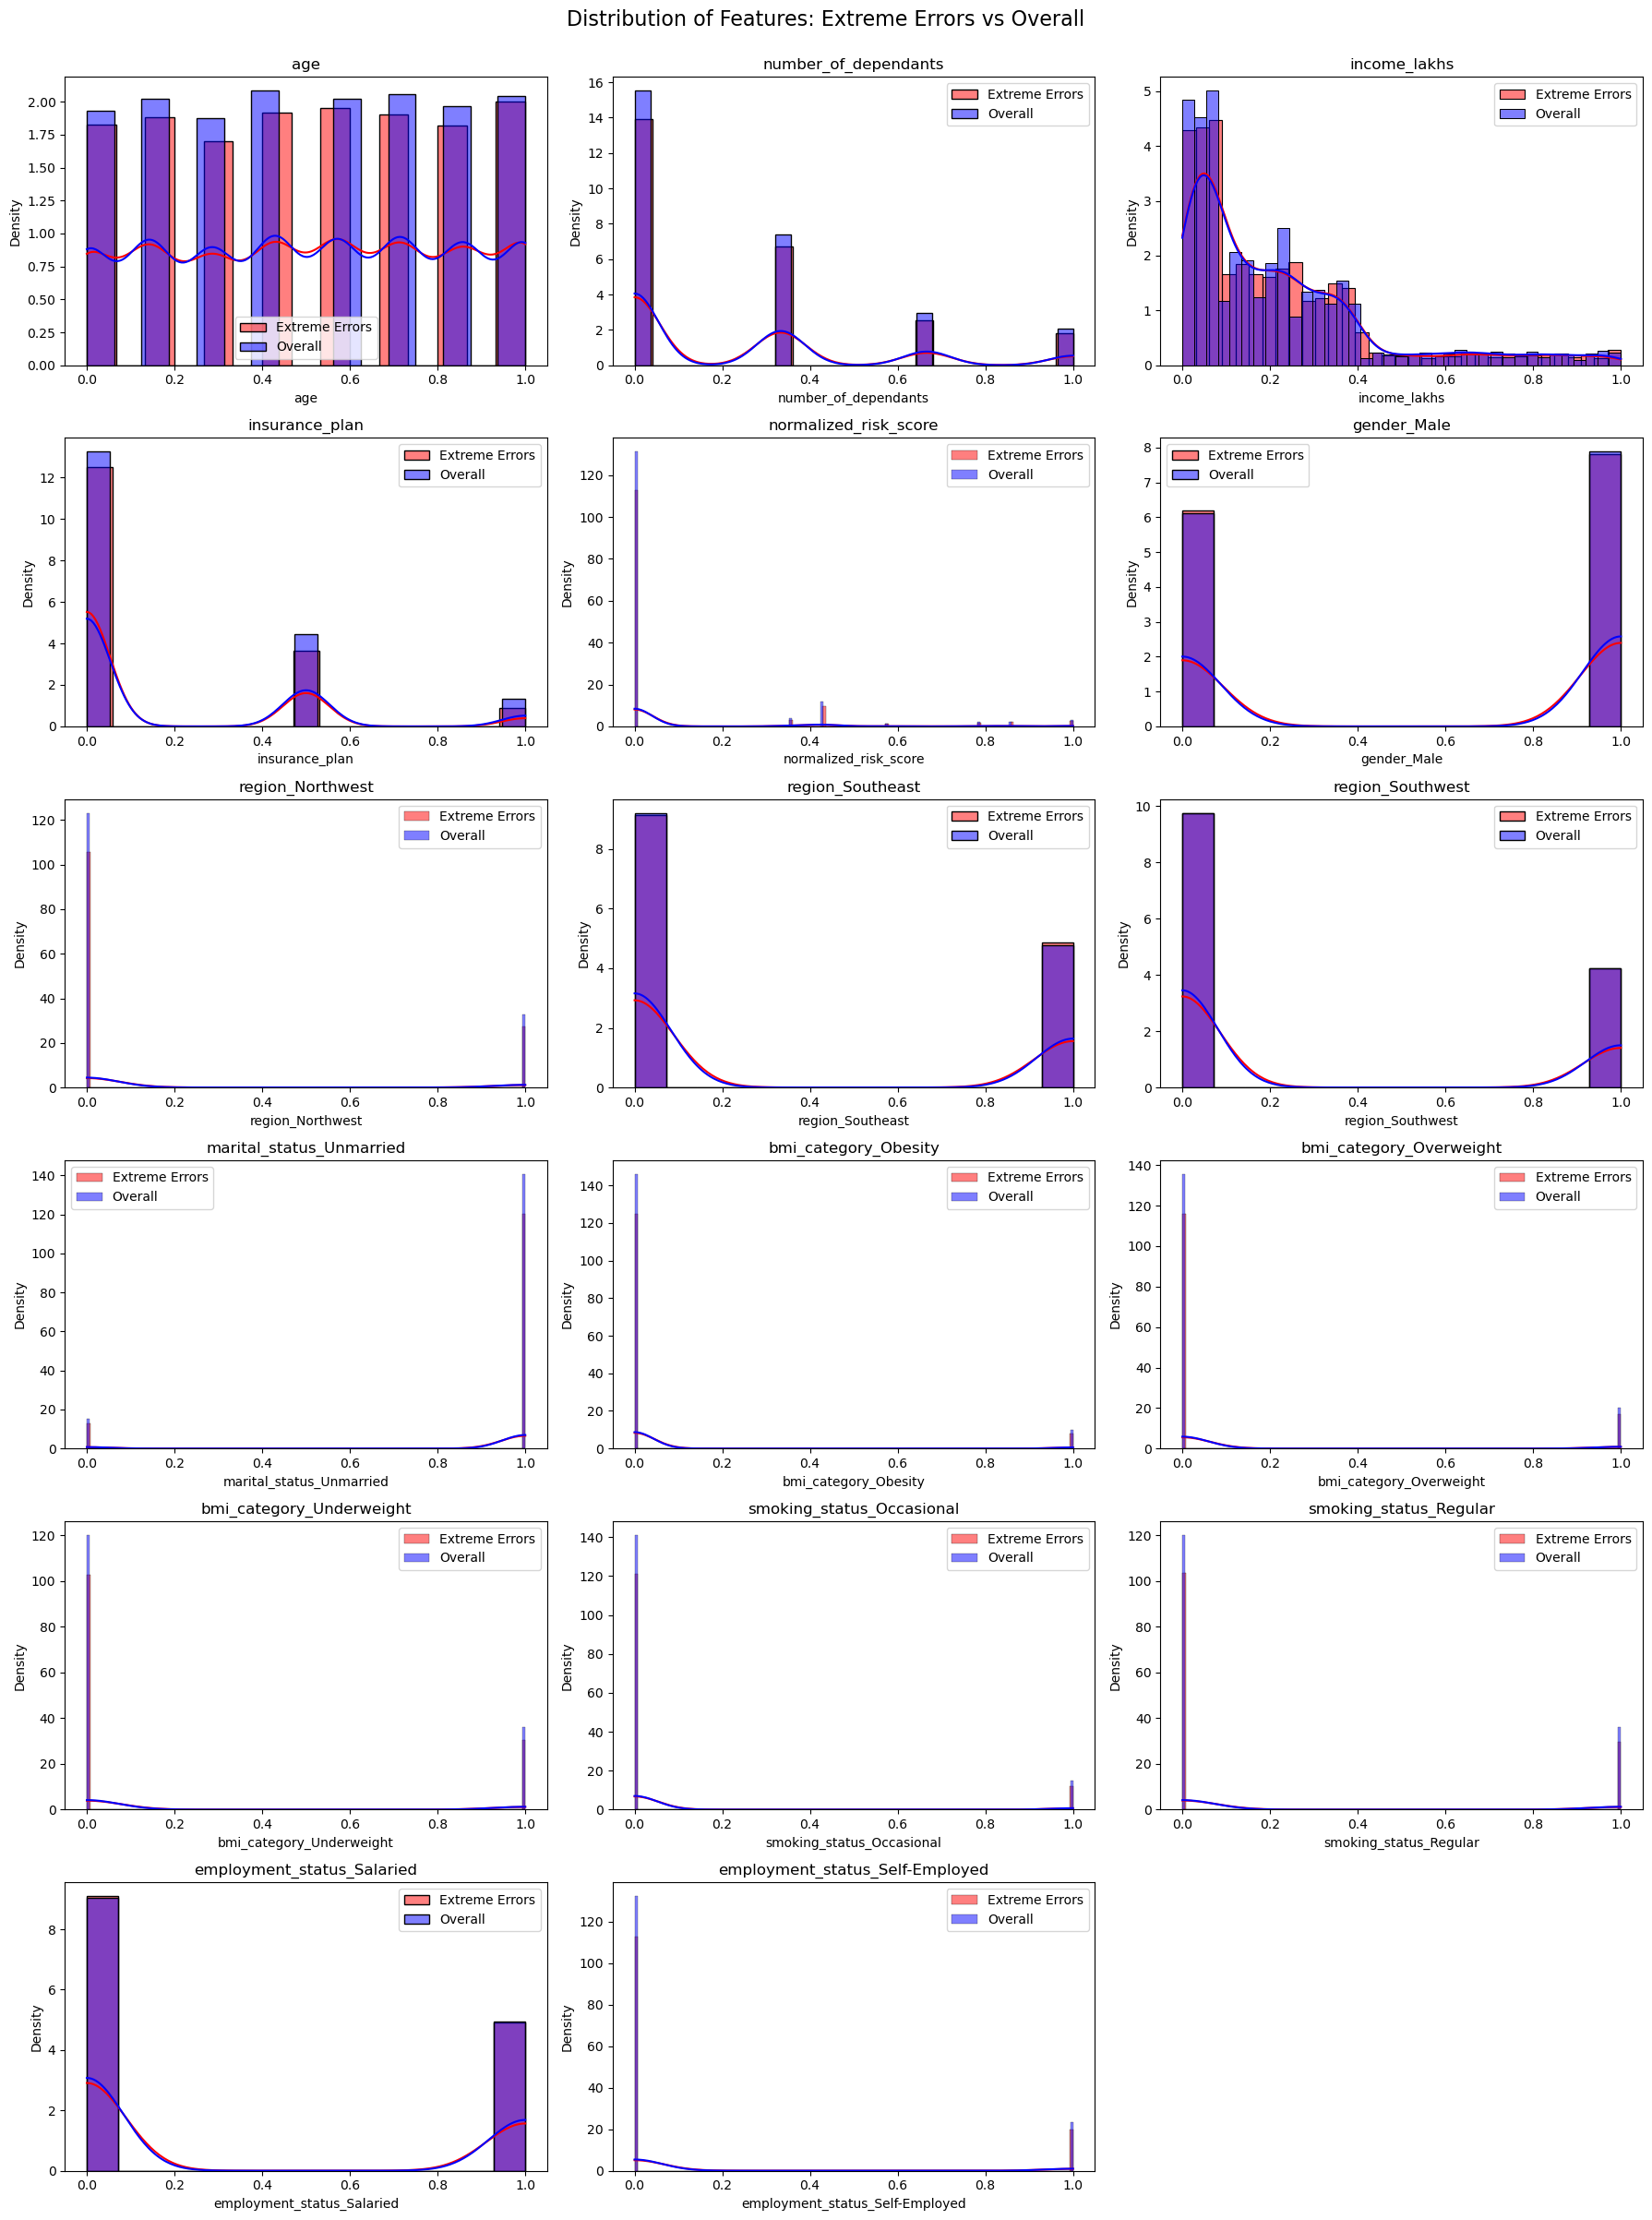

In [85]:
import math
features = X_test.columns
n_cols = 3
n_rows = math.ceil(len(features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = axes.flatten()

for ax, feature in zip(axes, features):
    sns.histplot(extreme_errors_df[feature], color='red', label='Extreme Errors',
                 kde=True, stat='density', common_norm=False, ax=ax)
    sns.histplot(X_test[feature], color='blue', label='Overall', alpha=0.5,
                 kde=True, stat='density', common_norm=False, ax=ax)
    ax.set_title(f'{feature}')
    ax.legend()

for ax in axes[len(features):]:
    ax.set_visible(False)

fig.suptitle('Distribution of Features: Extreme Errors vs Overall', fontsize=16, y=1.0)
plt.tight_layout()
plt.show()

The distribution of extreme error df and age is not same, so there we need to solve the issue

### Reverse Scaling

In [86]:
extreme_errors_df['income_level']=-1

In [87]:
df_reversed = pd.DataFrame()
df_reversed[cols_to_scale] = scaler.inverse_transform(extreme_errors_df[cols_to_scale])
df_reversed.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan
0,20.0,1.0,-2.0,4.0,1.0
1,25.0,0.0,-2.0,9.0,1.0
2,22.0,0.0,-2.0,58.0,2.0
3,20.0,0.0,-2.0,3.0,1.0
4,24.0,0.0,-2.0,7.0,1.0


In [88]:
df_reversed.describe()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan
count,4365.000000,4365.000000,4365.0,4365.000000,4365.000000
mean,21.551203,0.691638,-2.0,21.752577,1.318442
std,2.295425,0.925866,0.0,21.362894,0.567482
min,18.000000,0.000000,-2.0,1.000000,1.000000
25%,20.000000,0.000000,-2.0,6.000000,1.000000
50%,22.000000,0.000000,-2.0,15.000000,1.000000
75%,24.000000,1.000000,-2.0,31.000000,2.000000
max,25.000000,3.000000,-2.0,100.000000,3.000000


In [89]:
df_reversed["age"].quantile(0.99)

np.float64(25.0)

<Axes: xlabel='age', ylabel='Count'>

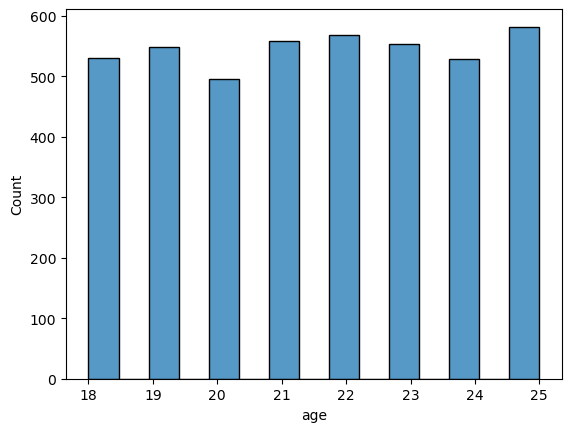

In [90]:
sns.histplot(df_reversed.age)

Majority of extreme error from young age